<a href="https://colab.research.google.com/github/SonJorell/Challenge-Alura-Latam---TelecomX_LATAM--Parte-2/blob/main/Challenge_Alura_Latam_TelecomX_LATAM_Parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom X - Parte 2: Modelado Predictivo de Churn
En este notebook, realizaremos la transición de analistas de datos a científicos de datos. El objetivo es construir modelos de aprendizaje automático que permitan predecir qué clientes tienen mayor probabilidad de abandonar la empresa.

# 1. Configuración e Importación de Librerías
Cargamos las herramientas de procesamiento, visualización y los algoritmos de Scikit-Learn.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# Herramientas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score

# Configuración de estilo
sns.set_theme(style="whitegrid")
%matplotlib inline

# 2. Extracción y Limpieza Básica
Cargamos los datos desde la fuente original y aplicamos la limpieza esencial realizada en la Parte 1 para asegurar la calidad de la entrada.

In [11]:
# Carga de datos
url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
response = requests.get(url)
df = pd.json_normalize(response.json())
df.columns = [col.replace('.', '_') for col in df.columns]

# Limpieza esencial
df = df[df['Churn'] != ""].copy()
df['account_Charges_Total'] = pd.to_numeric(df['account_Charges_Total'], errors='coerce')
df['account_Charges_Total'] = df['account_Charges_Total'].fillna(df['account_Charges_Monthly'])

# Eliminación de columnas irrelevantes para el modelo (como IDs)
df_ml = df.drop(columns=['customerID'])

print(f"Dataset cargado y preparado. Registros: {df_ml.shape[0]}")

Dataset cargado y preparado. Registros: 7043


# 3. Preprocesamiento (Encoding)
Convertimos las variables categóricas en numéricas utilizando One-Hot Encoding para que los modelos puedan procesar la información.

In [12]:
# Transformar variables categóricas (Encoding)
# Seleccionamos columnas de tipo objeto (excepto la variable objetivo Churn)
cols_categoricas = df_ml.select_dtypes(include=['object']).columns.drop('Churn')

# Aplicar get_dummies
df_ml = pd.get_dummies(df_ml, columns=cols_categoricas, drop_first=True)

# Convertir la variable objetivo 'Churn' a binario (1 y 0)
df_ml['Churn'] = df_ml['Churn'].map({'Yes': 1, 'No': 0})

print(f"Dimensiones después del Encoding: {df_ml.shape}")
df_ml.head()

Dimensiones después del Encoding: (7043, 31)


,Churn,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,account_Charges_Total,customer_gender_Male,customer_Partner_Yes,customer_Dependents_Yes,phone_PhoneService_Yes,phone_MultipleLines_No phone service,...,internet_StreamingTV_No internet service,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0,0,9,65.6,593.30,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0,0,9,59.9,542.40,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,1,0,4,73.9,280.85,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1,1,13,98.0,1237.85,True,True,False,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1,1,3,83.9,267.40,False,True,False,True,False,...,False,True,False,False,False,False,True,False,False,True


# 4. Análisis de Correlación
Identificamos qué factores tienen mayor peso matemático en la decisión de los clientes de irse.

/tmp/ipykernel_137/1109093923.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlaciones.values, y=correlaciones.index, palette='coolwarm')


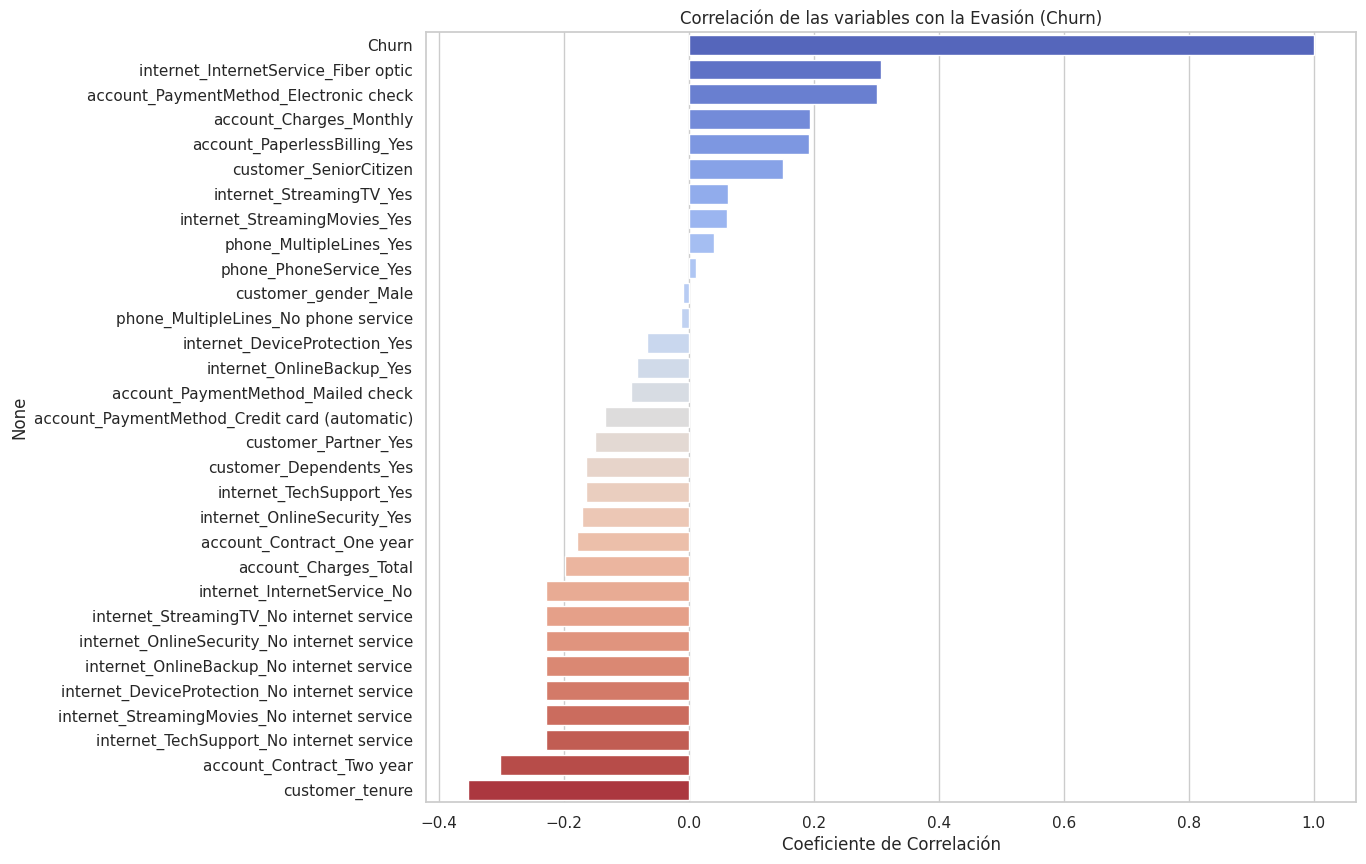

In [13]:
plt.figure(figsize=(12, 10))
# Correlación con respecto a Churn
correlaciones = df_ml.corr()['Churn'].sort_values(ascending=False)

sns.barplot(x=correlaciones.values, y=correlaciones.index, palette='coolwarm')
plt.title("Correlación de las variables con la Evasión (Churn)")
plt.xlabel("Coeficiente de Correlación")
plt.show()

# 5. División y Escalamiento de Datos
Separamos los datos en conjuntos de entrenamiento (para que el modelo aprenda) y prueba (para evaluar su desempeño real).

In [14]:
# Definir variables independientes (X) y variable objetivo (y)
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

# División 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Escalamiento (Necesario para Regresión Logística y modelos basados en distancias)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos divididos y escalados.")

Datos divididos y escalados.


# 6. Creación y Evaluación de Modelos
Entrenaremos dos modelos distintos: uno basado en relaciones lineales y otro en árboles de decisión.

# Modelo 1: Regresión Logística

In [15]:
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)

# Modelo 2: Random Forest

In [16]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train) # Los árboles no requieren escalamiento
y_pred_rf = model_rf.predict(X_test)

# 7. Evaluación Comparativa
Evaluamos las métricas de desempeño para decidir cuál modelo es más útil para el negocio.

/tmp/ipykernel_137/497868102.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='account_Charges_Monthly', data=df, palette='Set2')


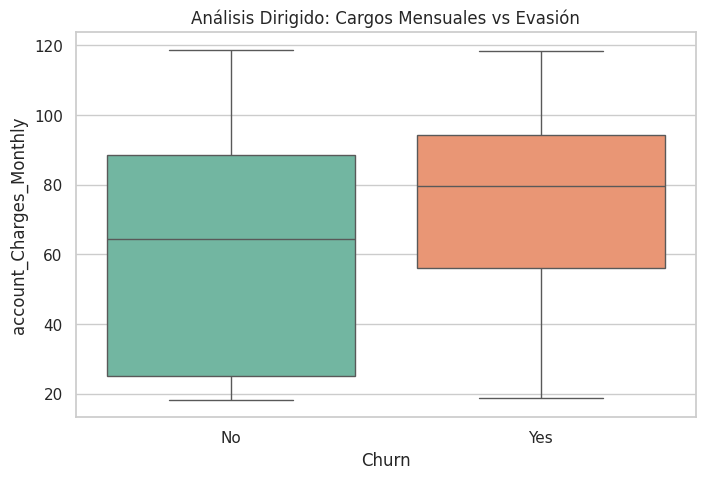


--- Regresión Logística ---
Exactitud: 0.7979
Recall (Sensibilidad): 0.5455

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1552
           1       0.64      0.55      0.59       561

    accuracy                           0.80      2113
   macro avg       0.74      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113



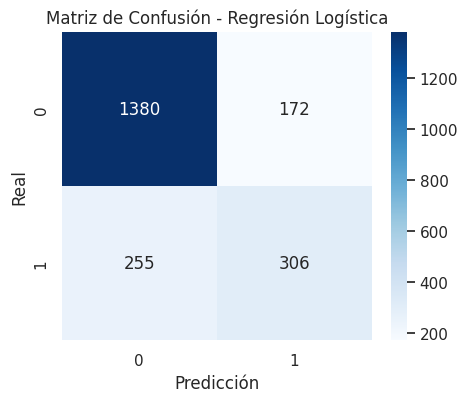


--- Random Forest ---
Exactitud: 0.7870
Recall (Sensibilidad): 0.4813

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1552
           1       0.63      0.48      0.55       561

    accuracy                           0.79      2113
   macro avg       0.73      0.69      0.70      2113
weighted avg       0.77      0.79      0.78      2113



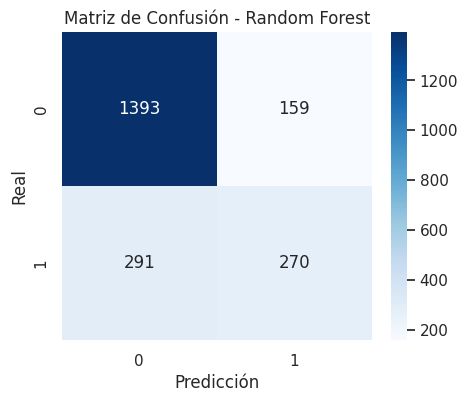

In [17]:
def mostrar_reporte(nombre, y_real, y_pred):
    print(f"\n--- {nombre} ---")
    print(f"Exactitud: {accuracy_score(y_real, y_pred):.4f}")
    print(f"Recall (Sensibilidad): {recall_score(y_real, y_pred):.4f}")
    print("\nReporte de Clasificación:")
    print(classification_report(y_real, y_pred))

    # Matriz de Confusión
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_real, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"Matriz de Confusión - {nombre}")
    plt.ylabel("Real")
    plt.xlabel("Predicción")
    plt.show()

    # Análisis Dirigido: Gasto Mensual vs Cancelación
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='account_Charges_Monthly', data=df, palette='Set2')
plt.title('Análisis Dirigido: Cargos Mensuales vs Evasión')
plt.show()

mostrar_reporte("Regresión Logística", y_test, y_pred_lr)
mostrar_reporte("Random Forest", y_test, y_pred_rf)

# 8. Importancia de las Variables
Visualizamos qué variables son las más determinantes para el modelo de Random Forest.

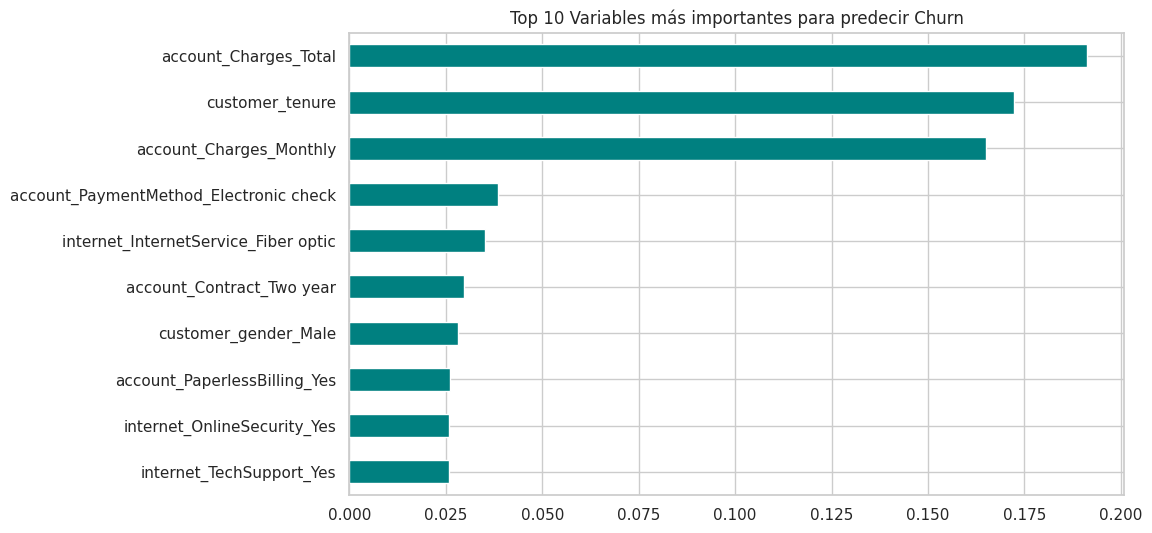

In [18]:
importancias = pd.Series(model_rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
importancias.plot(kind='barh', color='teal')
plt.title("Top 10 Variables más importantes para predecir Churn")
plt.gca().invert_yaxis()
plt.show()

# 9. Conclusión Estratégica


1.   **Rendimiento**: El modelo de Regresión Logística mostró un equilibrio sólido, pero el Random Forest nos permite identificar de mejor manera la importancia de las variables no lineales.
2.   **Factores Clave:** Los clientes con contratos mensuales y el uso de servicios de fibra óptica son los perfiles con mayor riesgo.
3.   **Acción Recomendada:** Se recomienda al equipo de marketing enfocar campañas de fidelización y soporte técnico preventivo en clientes que utilicen fibra óptica y tengan menos de un año de permanencia.

